# Local Chern marker (Bianco–Resta)

We compute the Bianco–Resta local Chern marker for a finite Haldane patch: first verify the bulk Chern number in momentum space, then build an open-boundary supercell and map the real-space marker, trimming the boundary to recover the bulk value.

:::{admonition} What you will learn
:class: tip
- Instantiate the Haldane model and verify its bulk Chern number on a Brillouin-zone mesh.
- Generate a large open-boundary patch with `make_finite` and evaluate the local Chern marker.
- Aggregate site-resolved markers into unit-cell values, trim edges, and estimate the bulk topological index.
- Visualize the spatial distribution of the marker to spot edge currents versus bulk plateaus.
:::

In [1]:
from pythtb import TBModel, Mesh, WFArray

import numpy as np
import matplotlib.pyplot as plt
from pythtb.models import haldane

## Periodic benchmark

Construct the topological Haldane model ($\Delta=0$, $t=1$, $t_2=0.15$), check its built-in Chern number, and reproduce it via `WFArray` on a $50\times 50$ Monkhorst–Pack mesh.

In [2]:
model = haldane(0, 1, 0.15)
print(model)

----------------------------------------
       Tight-binding model report       
----------------------------------------
r-space dimension           = 2
k-space dimension           = 2
spinful                     = False
periodic directions         = [0, 1]
number of spin components   = 1
number of electronic states = 2
number of orbitals          = 2

Lattice vectors (Cartesian):
  # 0 ===> [ 1.000,  0.000]
  # 1 ===> [ 0.500,  0.866]
Volume of unit cell (Cartesian) = 0.866 [A^d]

Reciprocal lattice vectors (Cartesian):
  # 0 ===> [ 6.283, -3.628]
  # 1 ===> [ 0.000,  7.255]
Volume of reciprocal unit cell = 45.586 [A^-d]

Orbital vectors (Cartesian):
  # 0 ===> [ 0.500,  0.289]
  # 1 ===> [ 1.000,  0.577]
Orbital vectors (fractional):
  # 0 ===> [ 0.333,  0.333]
  # 1 ===> [ 0.667,  0.667]
----------------------------------------
Site energies:
  # 0 ===>  0.000 
  # 1 ===>  0.000 
Hoppings:
  < 0 | H | 1 >  ===> 1.0000+0.0000j
  < 0 | H | 1 + [-1.0 ,  0.0 ] >  ===> 1.0000+0.0000j
 

In [3]:
mesh = Mesh(dim_k=2, axis_types=['k','k'])
mesh.build_grid(shape=(50, 50))
wfa = WFArray(model.lattice, mesh)
wfa.solve_model(model)


chern_band0 = wfa.chern_num(state_idx=[0], plane=(0, 1)).item()
print(f"Chern number (valence band): {chern_band0:+.3f}")

Chern number (valence band): -1.000


## Open-boundary patch

Cut a large rectangular patch by repeating the unit cell $(L_x, L_y)$ times with `model.make_finite`. This returns a purely real-space `TBModel` (no k-axes) ready for local-marker evaluation.

In [4]:
# Finite OBC patch: (Lx, Ly) supercell
Lx, Ly = 40, 24
finite_model = model.make_finite(periodic_dirs=[0,1], num_cells=[Lx, Ly])

## Site-resolved marker

`TBModel.local_chern_marker()` yields the Bianco–Resta marker per orbital. We reshape it into unit-cell sums, trim a margin in the real-space coordinates, and average what remains to approximate the bulk value.

In [5]:
C_r = finite_model.local_chern_marker()

In [6]:
num_orb = finite_model.norb // (Lx * Ly)
marker_cell = C_r.reshape(Lx * Ly, num_orb).sum(axis=1)

positions = finite_model.get_orb_vecs(cartesian=True).reshape(Lx * Ly, num_orb, 2).mean(axis=1)
x, y = positions[:, 0], positions[:, 1]

trim = 8.0  # tune as needed
mask = (
      (x > x.min() + trim)
    & (x < x.max() - trim)
    & (y > y.min() + trim)
    & (y < y.max() - trim)
)
bulk_estimate = marker_cell[mask].mean()
print(f"Trimmed bulk marker (trim={trim:.1f}): {bulk_estimate:+.3f}")

Trimmed bulk marker (trim=8.0): -0.999


## Visualise edge vs bulk

Color the orbitals by their marker value to show bulk plateaus (≈ Chern number) and boundary oscillations.

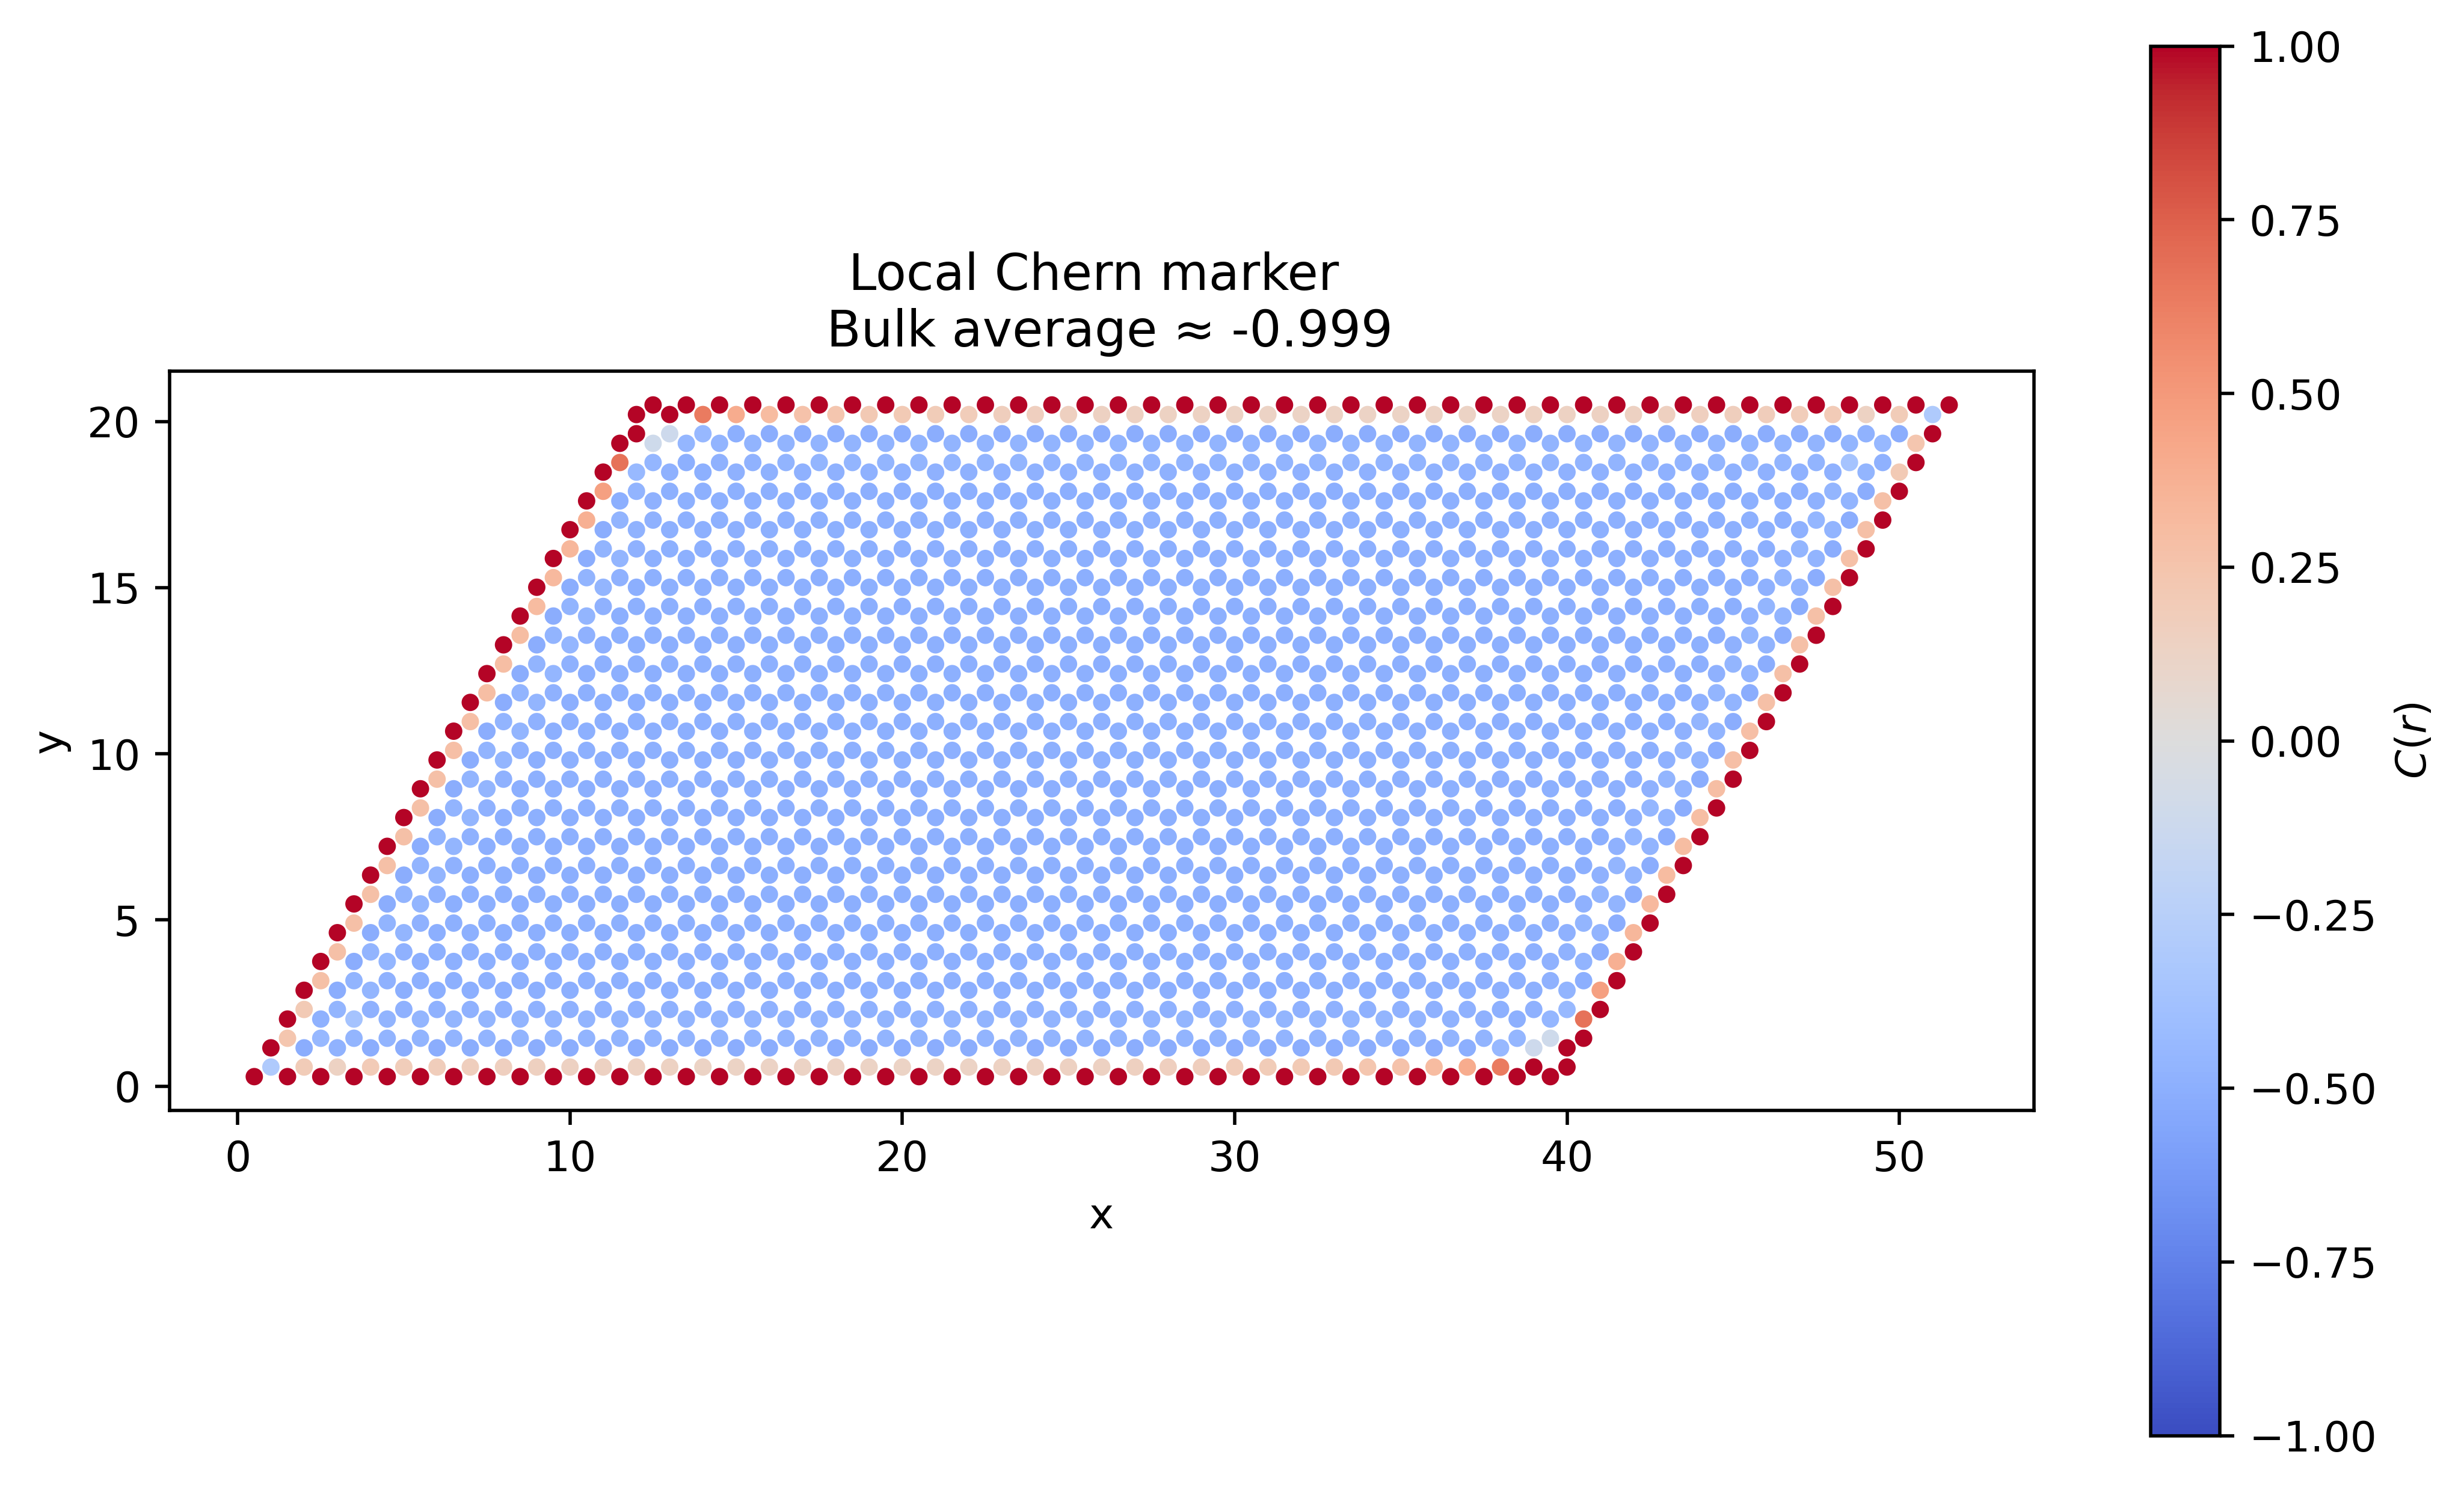

In [7]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=500)
pos = finite_model.get_orb_vecs(cartesian=True)
sc = ax.scatter(
    pos[:, 0],
    pos[:, 1],
    c=C_r,
    s=10,
    cmap="coolwarm",
    vmin=-1.0,
    vmax=1.0,
)
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(f"Local Chern marker \n Bulk average ≈ {bulk_estimate:+.3f}")
fig.colorbar(sc, ax=ax, label=r"$C(r)$")

:::{note}
- Increase `Lx`, `Ly`, or adjust `trim` if the bulk plateau hasn’t converged.
- `C_r` is complex in principle; here it’s real up to numerical noise. Take `.real` if needed.
- `make_finite` keeps the cell ordering consistent with `reshape` above; if you use `cut_piece` chains, check the order before aggregating.
:::

:::{admonition} Next steps
:class: seealso
- Sweep $(\delta, t_2)$ to watch the local marker transition between $0$ and $\pm1$, and correlate with gap closings.
- Compare `local_chern_marker` with hybrid Wannier flow for the same finite region.
:::